# MXF tick microstructure — what execution actually costs

Bid/ask ticks are the only data that let us **measure** execution cost instead of assuming it.
That matters here because two of our conclusions rest on assumed numbers:

- the stop-loss study concluded the ACE loss was **execution-layer, not signal**
- `cta.backtest_live.Costs` charges `slippage_points = 1.0` per side, documented as
  *"median MTX bid-ask over 2023+ is 3.0 points, so 1.5 = paying the full half-spread;
  1.0 assumes you capture a little via the closing auction"*

This notebook tests that assumption against real quotes.

## Data

`cta.load_ticks` / `cta.tick_quotes` read per-day parquet from
`s3://reggie-f-cache-tw/shioaji/ticks/MXFR1/`, cached locally under `~/.f_cache/tw/shioaji/`.
Written by the `shioaji-ingest` repo; the backfill is bounded per run, so coverage grows
over several days.

**Contract naming:** `MXF` is 小型臺指期貨 (小台, multiplier 50). `TXF` is 大台 (multiplier 200).

**Session convention:** the night session for trading day *t* opens 15:00 on *t−1*. Grouping
by calendar date splits one session across two rows — `cta.session_date` handles this, and
`tick_daily_summary(by_session=True)` is the default for that reason.

In [1]:
import importlib, sys, warnings
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore", message="findfont: .* not found")
_inst = {f.name for f in fm.fontManager.ttflist}
_cand = ["Hiragino Sans GB","Heiti TC","Songti SC","PingFang HK","PingFang SC","PingFang TC",
         "Arial Unicode MS","Noto Sans CJK TC","DejaVu Sans"]
mpl.rcParams["font.family"] = [f for f in _cand if f in _inst] or ["DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

import cta
for _m in ["cta.ticks","cta.backtest_live"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

SYMBOL     = "MXFR1"
MULTIPLIER = 50        # 小台. 大台 (TXF) is 200.

days = cta.available_tick_days(SYMBOL)
print(f"{SYMBOL}: {len(days)} days on S3, {days[0]} .. {days[-1]}")

MXFR1: 55 days on S3, 20260618 .. 20260902


## 1. Load and check coverage

The backfill runs a bounded number of days per session, so gaps while it catches up are
expected rather than a bug. Check before drawing conclusions from a date range.

In [2]:
q = cta.tick_quotes(SYMBOL, verbose=True)
q["session"] = cta.session_date(q["ts"])

cov = q.groupby("session").size()
print(f"\nsessions: {len(cov)}   ticks: {len(q):,}   mean {cov.mean():,.0f}/session")
print(f"span: {cov.index.min():%Y-%m-%d} .. {cov.index.max():%Y-%m-%d}")
q.head(3)

MXFR1: 10,607,903 ticks over 55 days (20260618..20260902)

sessions: 64   ticks: 10,607,709   mean 165,745/session
span: 2026-06-18 .. 2026-09-02


,ts,close,volume,bid_price,bid_volume,ask_price,ask_volume,tick_type,mid,spread,spread_bps,depth_imb,signed_vol,eff_spread,session
0,2026-06-17 15:00:00.030,46123.0,1,46123.0,1,46125.0,7,1,46124.0,2.0,0.433614,-0.75,-1.0,2.0,2026-06-18
1,2026-06-17 15:00:00.030,46122.0,1,46123.0,1,46125.0,7,1,46124.0,2.0,0.433614,-0.75,-1.0,4.0,2026-06-18
2,2026-06-17 15:00:00.030,46121.0,3,46123.0,1,46125.0,7,1,46124.0,2.0,0.433614,-0.75,-3.0,6.0,2026-06-18


## 2. Quoted spread — testing the 3.0-point claim

`Costs` asserts a 3.0-point median. Ticks can confirm or refute it directly.

In [3]:
desc = q["spread"].describe(percentiles=[.05,.25,.5,.75,.95,.99])
print(desc.to_string())
print(f"\nmedian quoted spread : {q['spread'].median():.2f} pts"
      f"  = {q['spread'].median()*MULTIPLIER:,.0f} TWD/contract")
print(f"half-spread          : {q['spread'].median()/2:.2f} pts"
      f"  = {q['spread'].median()/2*MULTIPLIER:,.0f} TWD/side")
print(f"Costs assumes        : 1.00 pts  = {1.0*MULTIPLIER:,.0f} TWD/side")

vc = q["spread"].value_counts(normalize=True).sort_index().head(8)
print("\nspread distribution (pts -> share):")
for k,v in vc.items(): print(f"  {k:5.0f}  {v*100:5.1f}%")

count    1.060771e+07
mean     3.470049e+00
std      3.209119e+00
min      1.000000e+00
5%       1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
95%      5.000000e+00
99%      9.000000e+00
max      2.970000e+02

median quoted spread : 3.00 pts  = 150 TWD/contract
half-spread          : 1.50 pts  = 75 TWD/side
Costs assumes        : 1.00 pts  = 50 TWD/side

spread distribution (pts -> share):
      1    7.4%
      2   18.3%
      3   29.3%
      4   33.2%
      5    6.8%
      6    2.2%
      7    1.0%
      8    0.5%


## 3. Effective spread — what a marketable order actually pays

Quoted spread is what you see; **effective spread** `2·|trade − mid|` is what you pay. They
differ when trades occur outside the quoted book or the book moves against you. This is the
number `slippage_points` should be compared against.

In [4]:
eff_half = q["eff_spread"].mean()/2
print(f"mean effective spread : {q['eff_spread'].mean():.2f} pts")
print(f"  -> per side         : {eff_half:.2f} pts = {eff_half*MULTIPLIER:,.0f} TWD")
print(f"median effective      : {q['eff_spread'].median():.2f} pts")
print()
print(f"Costs slippage_points : 1.00 pts = {1.0*MULTIPLIER:,.0f} TWD/side")
print(f"understatement factor : {eff_half/1.0:.2f}x")

from cta.backtest_live import Costs
c = Costs()
px = q['mid'].median()
assumed = c.commission_twd + c.tax_rate*px*MULTIPLIER + c.slippage_points*MULTIPLIER
measured= c.commission_twd + c.tax_rate*px*MULTIPLIER + eff_half*MULTIPLIER
print(f"\nper-side cost @ index {px:,.0f}:")
print(f"  as modelled : {assumed:6.1f} TWD")
print(f"  as measured : {measured:6.1f} TWD   ({measured/assumed:.2f}x)")

mean effective spread : 4.79 pts
  -> per side         : 2.40 pts = 120 TWD
median effective      : 4.00 pts

Costs slippage_points : 1.00 pts = 50 TWD/side
understatement factor : 2.40x

per-side cost @ index 45,192:
  as modelled :  115.2 TWD
  as measured :  185.0 TWD   (1.61x)


## 4. When is it cheapest to trade?

Spread is not constant through the session. If a signal can choose its execution window,
this is the map — and it is invisible in daily bars.

    spread       eff      vol        n    twd_side
ts                                                
0      3.0  3.788090   542569   372573   94.702246
1      3.0  3.764221   336116   232981   94.105528
2      3.0  4.872772   285782   203728  121.819288
3      3.0  4.969681   234101   168905  124.242030
4      4.0  7.965341   191558   139328  199.133519
5      7.5  7.500000        4        2  187.500000
8      5.0  8.493694   632377   439189  212.342351
9      4.0  5.458735  2576036  1828483  136.468373
10     3.0  4.564280  1486731  1024465  114.106997
11     3.0  4.219116  1068961   725215  105.477893
12     3.0  3.969218   860974   578614   99.230446
13     3.0  4.579960   861463   562109  114.499012
15     4.0  5.764434   652996   454484  144.110849
16     3.0  4.444060   556077   374301  111.101493
17     3.0  3.966787   403023   268511   99.169680
18     3.0  3.926234   319335   215396   98.155839
19     3.0  4.164014   405414   273360  104.100362
20     3.0  4.727155   521355  

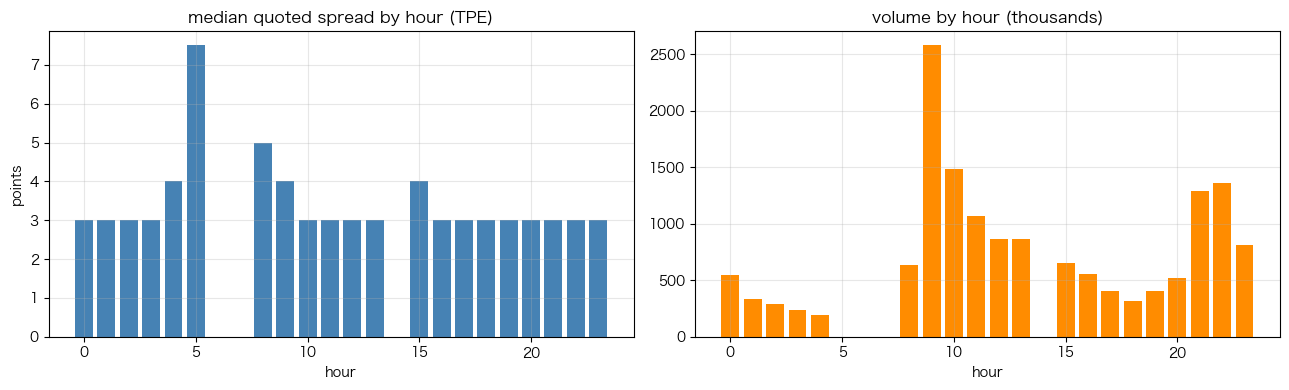

In [5]:
q["hhmm"] = q["ts"].dt.hour*60 + q["ts"].dt.minute
byh = q.groupby(q["ts"].dt.hour).agg(
    spread=("spread","median"), eff=("eff_spread","mean"),
    vol=("volume","sum"), n=("spread","size"))
byh["twd_side"] = byh["eff"]/2*MULTIPLIER
print(byh.to_string())

fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].bar(byh.index, byh["spread"], color="steelblue")
ax[0].set_title("median quoted spread by hour (TPE)"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("points")
ax[1].bar(byh.index, byh["vol"]/1e3, color="darkorange")
ax[1].set_title("volume by hour (thousands)"); ax[1].set_xlabel("hour")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Day vs night session

The MTX variants (`day` / `night` / `ongap` / `noonpause`) trade different windows. If night
liquidity is materially worse, a night-session signal needs a higher hurdle than a day one —
and the backtests currently charge both the same.

In [6]:
q["is_night"] = (q["ts"].dt.hour >= 15) | (q["ts"].dt.hour < 5)
sess = q.groupby("is_night").agg(
    spread_med=("spread","median"), eff_mean=("eff_spread","mean"),
    volume=("volume","sum"), ticks=("spread","size"))
sess.index = ["day 08:45-13:45","night 15:00-05:00"]
sess["twd_per_side"] = sess["eff_mean"]/2*MULTIPLIER
sess["vol_share"]    = sess["volume"]/sess["volume"].sum()
print(sess.to_string())
ratio = sess.loc['night 15:00-05:00','eff_mean']/sess.loc['day 08:45-13:45','eff_mean']
print(f"\nnight costs {ratio:.2f}x the day per side")

                   spread_med  eff_mean   volume    ticks  twd_per_side  vol_share
day 08:45-13:45           4.0  5.102357  7486546  5158077    127.558919   0.486284
night 15:00-05:00         3.0  4.501206  7908881  5449632    112.530158   0.513716

night costs 0.88x the day per side


## 6. Order-flow imbalance

`signed_vol` signs each trade by `tick_type` (外盤 buy / 內盤 sell). Aggregated per session
this is OFI — a candidate feature that simply does not exist in daily data.

In [7]:
daily = cta.tick_daily_summary(SYMBOL)
print(daily[["n_ticks","volume","spread_med","eff_spread_mean","ofi","close"]].tail(10).to_string())

ret = daily["close"].pct_change().shift(-1)   # next-session return
# rank correlation without scipy (not installed in this env)
ic  = daily["ofi"].rank().corr(ret.rank())
print(f"\nOFI vs next-session return, Spearman IC = {ic:+.3f}  (n={ret.notna().sum()})")
print("NOTE: a handful of sessions is far too few to mean anything. This is a")


            n_ticks  volume  spread_med  eff_spread_mean       ofi    close
date                                                                       
2026-08-22    68157  103738         3.0         3.591487  0.054416  45063.0
2026-08-24    74784  111643         3.0         4.140164  0.031950  44747.0
2026-08-25   160413  243183         3.0         4.093534 -0.017057  45031.0
2026-08-26   136487  209712         3.0         4.015298 -0.045963  46011.0
2026-08-27   126370  187923         3.0         3.726240  0.036430  46075.0
2026-08-28   121120  184143         3.0         3.439936  0.003367  46363.0
2026-08-29    75263  115695         3.0         3.448109  0.070625  45900.0
2026-08-31    74776  111732         3.0         4.120493 -0.005397  45990.0
2026-09-01   130772  195915         3.0         3.752837 -0.047133  47217.0
2026-09-02   137807  207420         3.0         3.480353  0.087417  46182.0

OFI vs next-session return, Spearman IC = -0.003  (n=63)
NOTE: a handful of sessions is

## 7. What to persist

Raw ticks are ~122 bytes/row in Postgres against ~12 as parquet — 10.6x — and a full
three-contract history would be ~52 GB against a database that is currently 40 GB in total.
So ticks stay in S3, and only per-session aggregates like `tick_daily_summary` (a few hundred
rows a year) belong in the DB, joinable to the existing signal tables.

In [8]:
print(daily.shape, "->", daily.memory_usage(deep=True).sum()/1e3, "KB in memory")
daily.tail(3)

(64, 10) -> 5.632 KB in memory


,n_ticks,volume,spread_mean,spread_med,spread_bps_mean,eff_spread_mean,depth_imb_mean,signed_vol,close,ofi
date,,,,,,,,,,
2026-08-31,74776,111732,3.096876,3.0,0.677751,4.120493,0.003376,-603.0,45990.0,-0.005397
2026-09-01,130772,195915,2.779983,3.0,0.598145,3.752837,-0.004226,-9234.0,47217.0,-0.047133
2026-09-02,137807,207420,2.788472,3.0,0.598081,3.480353,0.008961,18132.0,46182.0,0.087417
